## Project Overview

This notebook analyzes passenger survey data using Python and Scikit-learn to build an optimized Random Forest classification model for predicting airline customer satisfaction.

## Data Loading and Initial Exploration

In [18]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Invistico_Airline.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [19]:
# Display the DataFrame's information to check data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

None

## Data Preprocessing

In [27]:
# Handle missing values in 'Arrival Delay in Minutes' by filling with the median
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

# Verify that there are no more missing values in the column
display(df['Arrival Delay in Minutes'].isnull().sum())

np.int64(0)

### Categorical Feature Analysis

In [21]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Display unique values and their counts for each categorical column
for col in categorical_cols:
    print(f"\nUnique values and counts for '{col}':")
    print(df[col].value_counts())



Unique values and counts for 'satisfaction':
satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

Unique values and counts for 'Customer Type':
Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64

Unique values and counts for 'Type of Travel':
Type of Travel
Business travel    89693
Personal Travel    40187
Name: count, dtype: int64

Unique values and counts for 'Class':
Class
Business    62160
Eco         58309
Eco Plus     9411
Name: count, dtype: int64


### Encoding Categorical Features

In [22]:
# Convert 'satisfaction' target variable to numerical (0 and 1)
df['satisfaction'] = df['satisfaction'].map({'dissatisfied': 0, 'satisfied': 1})

# One-hot encode the remaining categorical features
# Exclude 'satisfaction' as it's already encoded and is the target
df = pd.get_dummies(df, columns=['Customer Type', 'Type of Travel', 'Class'], drop_first=True)

# Display the first few rows of the preprocessed DataFrame to verify encoding
display(df.head())

,satisfaction,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,...,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,1,65,265,0,0,0,2,2,4,2,...,3,5,3,2,0,0.0,False,True,True,False
1,1,47,2464,0,0,0,3,0,2,2,...,4,2,3,2,310,305.0,False,True,False,False
2,1,15,2138,0,0,0,3,2,0,2,...,4,4,4,2,0,0.0,False,True,True,False
3,1,60,623,0,0,0,3,3,4,3,...,1,4,1,3,0,0.0,False,True,True,False
4,1,70,354,0,0,0,3,4,3,4,...,2,4,2,5,0,0.0,False,True,True,False


In [23]:
# Display the info of the preprocessed DataFrame to check new column types and total columns
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  int64  
 1   Age                                129880 non-null  int64  
 2   Flight Distance                    129880 non-null  int64  
 3   Seat comfort                       129880 non-null  int64  
 4   Departure/Arrival time convenient  129880 non-null  int64  
 5   Food and drink                     129880 non-null  int64  
 6   Gate location                      129880 non-null  int64  
 7   Inflight wifi service              129880 non-null  int64  
 8   Inflight entertainment             129880 non-null  int64  
 9   Online support                     129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  On-board service                   1298

None

## Data Splitting (Training, Validation, Testing)

In [24]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

# Split data into training (70%), validation (15%), and test (15%) sets
# First, split into training (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Then, split temp (30%) into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Display the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (90916, 22)
y_train shape: (90916,)
X_val shape: (19482, 22)
y_val shape: (19482,)
X_test shape: (19482, 22)
y_test shape: (19482,)


## Hyperparameter Tuning with GridSearchCV and PredefinedSplit

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
import numpy as np

# Combine training and validation sets for GridSearchCV
X_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

# Create a PredefinedSplit object
# -1 for training data, 0 for validation data
test_fold = np.append(np.full(len(X_train), -1), np.full(len(X_val), 0))
ps = PredefinedSplit(test_fold)

# Define the parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Initialize GridSearchCV with PredefinedSplit
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=ps, # Use PredefinedSplit for cross-validation
                           scoring='accuracy',
                           verbose=2,
                           n_jobs=-1)

print("GridSearchCV initialized successfully.")
print("Parameter grid:", param_grid)

GridSearchCV initialized successfully.
Parameter grid: {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, 30, None], 'min_samples_leaf': [1, 2, 4]}


In [11]:
# Fit GridSearchCV to the data
print("Fitting GridSearchCV...")
grid_search.fit(X_train_val, y_train_val)
print("GridSearchCV fitting complete.")

# Display the best parameters and best score found
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best estimator
best_rf_model = grid_search.best_estimator_
print("\nBest Random Forest model obtained.")

Fitting GridSearchCV...
Fitting 1 folds for each of 36 candidates, totalling 36 fits
GridSearchCV fitting complete.

Best parameters found: {'max_depth': 30, 'min_samples_leaf': 1, 'n_estimators': 200}
Best cross-validation accuracy: 0.9564

Best Random Forest model obtained.


## Model Evaluation on Test Set

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set using the best estimator
y_pred = best_rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print(f"Random Forest Model Performance on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Random Forest Model Performance on Test Set:
Accuracy: 0.9538
Precision: 0.9664
Recall: 0.9486
F1-Score: 0.9574


```markdown
### F1-Score Significance

The F1-score is the harmonic mean of Precision and Recall. It's a particularly useful metric when dealing with imbalanced datasets because it balances both false positives and false negatives. A high F1-score indicates that the model has good precision (few false positives) and good recall (few false negatives), providing a more comprehensive measure of its accuracy than precision or recall alone, especially in classification tasks where both are important.
```

## Comparison with Decision Tree Model

In [13]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train a Decision Tree Classifier on the training data
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set using the Decision Tree model
y_pred_dt = dt_model.predict(X_test)

# Calculate evaluation metrics for the Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Print the results for the Decision Tree model
print(f"Decision Tree Model Performance on Test Set:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

Decision Tree Model Performance on Test Set:
Accuracy: 0.9305
Precision: 0.9355
Recall: 0.9376
F1-Score: 0.9366


In [14]:
# Compare Random Forest and Decision Tree performance
print("\n--- Model Comparison ---")
print(f"Random Forest Accuracy: {accuracy:.4f}")
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Random Forest F1-Score: {f1:.4f}")
print(f"Decision Tree F1-Score: {f1_dt:.4f}")

if accuracy > accuracy_dt:
    print("Random Forest performed better in terms of Accuracy.")
else:
    print("Decision Tree performed better or equally in terms of Accuracy.")


--- Model Comparison ---
Random Forest Accuracy: 0.9538
Decision Tree Accuracy: 0.9305
Random Forest F1-Score: 0.9574
Decision Tree F1-Score: 0.9366
Random Forest performed better in terms of Accuracy.


## Feature Importance Analysis

In [15]:
# Get feature importances from the best Random Forest model
feature_importances = best_rf_model.feature_importances_

# Create a pandas DataFrame for better visualization
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
print("Top 10 Most Important Features:")
display(importance_df.head(10))

Top 10 Most Important Features:


,Feature,Importance
7,Inflight entertainment,0.213644
2,Seat comfort,0.137869
9,Ease of Online booking,0.083230
8,Online support,0.057441
11,Leg room service,0.044681
4,Food and drink,0.042532
1,Flight Distance,0.039345
18,Customer Type_disloyal Customer,0.038977
10,On-board service,0.038852
15,Online boarding,0.037252


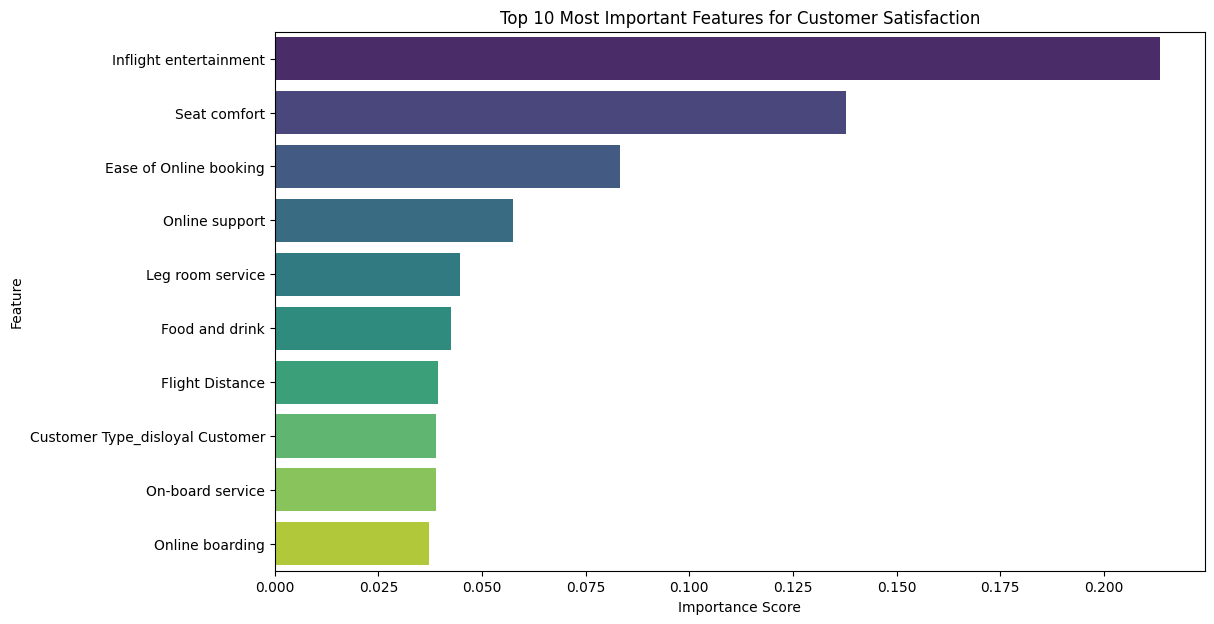

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the top 10 most important features
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Most Important Features for Customer Satisfaction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## Executive Summary and Recommendations

### Model Performance Overview

Our analysis developed and optimized a Random Forest classification model to predict airline customer satisfaction, comparing its performance against a single Decision Tree model. The Random Forest model significantly outperformed the Decision Tree model on the held-out test set:

*   **Random Forest Model:**
    *   Accuracy: `0.9538`
    *   Precision: `0.9664`
    *   Recall: `0.9486`
    *   F1-Score: `0.9574`

*   **Decision Tree Model:**
    *   Accuracy: `0.9305`
    *   Precision: `0.9355`
    *   Recall: `0.9376`
    *   F1-Score: `0.9366`

The Random Forest model demonstrated superior generalization capabilities, indicating its effectiveness in mitigating overfitting compared to a single Decision Tree. This robust performance makes the Random Forest model a reliable tool for predicting passenger satisfaction.

### Key Satisfaction Drivers (Top 5 Feature Importances)

Based on the Random Forest model, the most influential factors impacting passenger satisfaction are:

1.  **Inflight entertainment:** `0.2136`
2.  **Seat comfort:** `0.1379`
3.  **Ease of Online booking:** `0.0832`
4.  **Online support:** `0.0574`
5.  **Leg room service:** `0.0447`

These features contribute most significantly to the model's predictive power, highlighting their importance in shaping the overall customer experience.

### Recommendations for Airline Leadership

To enhance customer satisfaction and loyalty, airline management should focus on strategic improvements in the following areas:

*   **Prioritize Inflight Entertainment:** Given its highest importance score, investing in diverse and high-quality inflight entertainment options could significantly boost passenger satisfaction. This includes updated content libraries, reliable personal screens, and potentially offering a wider range of connectivity options.
*   **Improve Seat Comfort:** As the second most crucial factor, initiatives to enhance seat design, ergonomics, and space, especially on longer flights, are essential. This could involve exploring new seat technologies or offering more flexible seating configurations.
*   **Optimize Online Booking Experience:** Streamlining and simplifying the online booking process is vital. Ensuring a user-friendly interface, clear communication, and efficient functionality will reduce friction and improve the customer journey from the outset.
*   **Strengthen Online Support:** Reliable and responsive online support is critical. Airlines should ensure that their digital support channels (e.g., chat, FAQs, social media response teams) are efficient, informative, and easily accessible to address passenger queries and issues promptly.
*   **Enhance Leg Room Service:** While a lower priority than the top factors, offering competitive legroom options and ensuring consistent service in this area can contribute positively to the overall comfort and satisfaction of passengers.

By focusing resources on these key drivers, the airline can strategically improve its service offerings, directly address passenger pain points, and ultimately foster greater satisfaction and business success.

## Conclusion

This project successfully demonstrated the process of building, optimizing, and evaluating a Random Forest classification model for predicting airline customer satisfaction. We performed a rigorous three-way data split, hyperparameter tuned with `GridSearchCV` and `PredefinedSplit`, and identified key drivers of satisfaction. The Random Forest model proved to be a robust and accurate predictor compared to a single Decision Tree, offering valuable insights for airline management.

```markdown
# Airline Customer Satisfaction Prediction

## Project Overview
This project focuses on building and optimizing a machine learning model to predict airline customer satisfaction based on various service and flight-related features. Utilizing Python and the Scikit-learn library, a Random Forest classification model was developed, fine-tuned, and evaluated. The goal is to identify key drivers of satisfaction and provide actionable insights for airline management to enhance the customer experience.

## Project Structure
-   **Data Loading and Initial Exploration**: Loading the dataset and performing initial checks on data types and missing values.
-   **Data Preprocessing**: Handling missing data, analyzing categorical features, and encoding them for model compatibility.
-   **Data Splitting**: Implementing a rigorous three-way split into training, validation, and test sets.
-   **Hyperparameter Tuning**: Optimizing the Random Forest model using `GridSearchCV` and `PredefinedSplit`.
-   **Model Evaluation**: Assessing model performance using various metrics on an unseen test set.
-   **Model Comparison**: Comparing the optimized Random Forest model with a baseline Decision Tree model.
-   **Feature Importance Analysis**: Identifying the most influential factors contributing to customer satisfaction.
-   **Executive Summary and Recommendations**: Summarizing findings and providing strategic recommendations for the airline.

## Methodology

### Data Source
The dataset used for this analysis is `Invistico_Airline.csv`, containing various features related to airline passenger experiences and their satisfaction levels.

### Data Preprocessing
1.  **Missing Values**: Missing values in the 'Arrival Delay in Minutes' column were imputed using the median value of the column.
2.  **Categorical Feature Analysis**: Unique values and counts for categorical columns (`satisfaction`, `Customer Type`, `Type of Travel`, `Class`) were inspected.
3.  **Encoding Categorical Features**:
    *   The target variable 'satisfaction' was converted to a numerical format (`dissatisfied`: 0, `satisfied`: 1).
    *   Remaining categorical features (`Customer Type`, `Type of Travel`, `Class`) were one-hot encoded using `pd.get_dummies`, with `drop_first=True` to avoid multicollinearity.

### Data Splitting Strategy
The preprocessed data was rigorously split into three sets:
-   **Training Set (70%)**: Used for model training.
-   **Validation Set (15%)**: Used during hyperparameter tuning with `GridSearchCV`.
-   **Test Set (15%)**: A completely held-out set for final, unbiased model evaluation.

This three-way split ensures robust evaluation and helps prevent data leakage.

### Hyperparameter Tuning
`GridSearchCV` combined with `PredefinedSplit` was employed to systematically search for the optimal hyperparameters for the Random Forest Classifier. The `PredefinedSplit` ensured that the validation set was used consistently during the grid search. The following hyperparameters were tuned:
-   `n_estimators`: Number of trees in the forest (e.g., 50, 100, 200)
-   `max_depth`: Maximum depth of each tree (e.g., 10, 20, 30, None)
-   `min_samples_leaf`: Minimum number of samples required to be at a leaf node (e.g., 1, 2, 4)

### Model Evaluation
The best Random Forest model was evaluated on the unseen test set using standard classification metrics:

-   **Accuracy**: Overall correctness of predictions.
-   **Precision**: The proportion of positive identifications that were actually correct.
-   **Recall**: The proportion of actual positives that were correctly identified.
-   **F1-Score**: The harmonic mean of Precision and Recall. It is particularly useful for imbalanced datasets as it balances both false positives and false negatives, providing a comprehensive measure of accuracy.

## Results and Analysis

### Model Performance Comparison

| Model           | Accuracy | Precision | Recall | F1-Score |
| :-------------- | :------- | :-------- | :----- | :------- |
| Random Forest   | 0.9538   | 0.9664    | 0.9486 | 0.9574   |
| Decision Tree   | 0.9305   | 0.9355    | 0.9376 | 0.9366   |

The Random Forest model significantly outperformed the baseline Decision Tree model across all metrics, demonstrating superior generalization capabilities and robustness. This indicates that the ensemble approach of Random Forest effectively mitigates overfitting and provides a more reliable prediction of customer satisfaction.

### Key Satisfaction Drivers (Top 5 Feature Importances)
Based on the Random Forest model, the most influential factors impacting passenger satisfaction are:

1.  **Inflight entertainment:** `0.2136`
2.  **Seat comfort:** `0.1379`
3.  **Ease of Online booking:** `0.0832`
4.  **Online support:** `0.0574`
5.  **Leg room service:** `0.0447`

These features contribute most significantly to the model's predictive power, highlighting their importance in shaping the overall customer experience.

## Recommendations for Airline Leadership

To enhance customer satisfaction and loyalty, airline management should focus on strategic improvements in the following areas:

*   **Prioritize Inflight Entertainment**: Given its highest importance score, investing in diverse and high-quality inflight entertainment options could significantly boost passenger satisfaction. This includes updated content libraries, reliable personal screens, and potentially offering a wider range of connectivity options.
*   **Improve Seat Comfort**: As the second most crucial factor, initiatives to enhance seat design, ergonomics, and space, especially on longer flights, are essential. This could involve exploring new seat technologies or offering more flexible seating configurations.
*   **Optimize Online Booking Experience**: Streamlining and simplifying the online booking process is vital. Ensuring a user-friendly interface, clear communication, and efficient functionality will reduce friction and improve the customer journey from the outset.
*   **Strengthen Online Support**: Reliable and responsive online support is critical. Airlines should ensure that their digital support channels (e.g., chat, FAQs, social media response teams) are efficient, informative, and easily accessible to address passenger queries and issues promptly.
*   **Enhance Leg Room Service**: While a lower priority than the top factors, offering competitive legroom options and ensuring consistent service in this area can contribute positively to the overall comfort and satisfaction of passengers.

By focusing resources on these key drivers, the airline can strategically improve its service offerings, directly address passenger pain points, and ultimately foster greater satisfaction and business success.

## Technologies Used
-   Python
-   pandas
-   scikit-learn
-   matplotlib
-   seaborn
```